# Laboratorio 01 — De neuronas a Transformers: lo que necesitas saber
### Python AI Developer 2026 · Capítulo 1 LLMs y el ecosistema Python actual

---

**¿Por qué existe este laboratorio?**

En el Lab 01 vas a llamar a GPT, Claude y Llama como si fueran cajas negras. Eso funciona para tareas simples, pero cuando algo falla, cuando necesitas elegir entre modelos, o cuando tienes que diseñar un sistema real, necesitas saber qué hay adentro de esa caja.

Este lab te da exactamente eso: la intuición suficiente para dejar de tratar los LLMs como magia.

**Lo que aprenderás:**
1. Cómo funciona una neurona artificial (con matemática básica)
2. Cómo se entrenan redes neuronales (gradiente descendente, visual)
3. Cómo se representaba texto antes de los LLMs (y por qué era insuficiente)
4. Qué hace especial a la arquitectura Transformer

**Librerías que usaremos:** `numpy`, `matplotlib`, `sklearn`  
**Sin APIs, sin costos, sin internet requerido**

**Setup (en terminal):**
```bash
uv add numpy matplotlib scikit-learn
```

---
## REPASO RÁPIDO — NumPy y Matplotlib en 5 minutos

Si ya los conoces, ejecuta las celdas y sigue adelante. Si no, léelas con cuidado.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# NumPy: arrays matemáticos eficientes
# Un vector (1D)
v = np.array([1.0, 2.0, 3.0])

# Una matriz (2D)
M = np.array([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0]
])

# Multiplicación de matrices: el corazón matemático de las redes neuronales
# M tiene forma (3, 2) y v2 forma (2,) → el resultado tiene forma (3,)
v2 = np.array([0.5, -0.5])
resultado = M @ v2   # @ es el operador de multiplicación de matrices en Python

print("Vector v2:", v2)
print("Matriz M:\n", M)
print("M @ v2 =", resultado)
print()
print(" Cada elemento del resultado es el 'dot product' de una fila de M con v2.")
print(f"   Fila 0: {M[0]} · {v2} = {M[0] @ v2:.1f}")
print(f"   Fila 1: {M[1]} · {v2} = {M[1] @ v2:.1f}")
print(f"   Fila 2: {M[2]} · {v2} = {M[2] @ v2:.1f}")

Vector v2: [ 0.5 -0.5]
Matriz M:
 [[1. 2.]
 [3. 4.]
 [5. 6.]]
M @ v2 = [-0.5 -0.5 -0.5]

 Cada elemento del resultado es el 'dot product' de una fila de M con v2.
   Fila 0: [1. 2.] · [ 0.5 -0.5] = -0.5
   Fila 1: [3. 4.] · [ 0.5 -0.5] = -0.5
   Fila 2: [5. 6.] · [ 0.5 -0.5] = -0.5


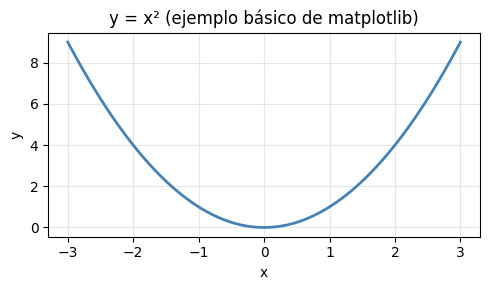

In [3]:
# Matplotlib: visualización
x = np.linspace(-3, 3, 100)   # 100 puntos entre -3 y 3
y = x ** 2                     # función cuadrática

plt.figure(figsize=(5, 3))
plt.plot(x, y, color='steelblue', linewidth=2)
plt.title("y = x² (ejemplo básico de matplotlib)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## PARTE 1 — La neurona artificial

### 1.1 ¿Qué es una neurona?

Una neurona biológica recibe señales de otras neuronas, las suma, y si la suma supera un umbral, dispara una señal hacia adelante.

Una neurona artificial hace exactamente lo mismo, pero con números:

```
entradas (x)  →  [suma ponderada + bias]  →  [función de activación]  →  salida
```

La fórmula es:

$$\text{salida} = f\left(\sum_{i} w_i \cdot x_i + b\right) = f(\mathbf{w} \cdot \mathbf{x} + b)$$

Donde:
- **x** = entradas (los datos)
- **w** = pesos (lo que el modelo *aprende*)
- **b** = bias (un ajuste adicional que también se aprende)
- **f** = función de activación (introduce no-linealidad)

La **multiplicación de matrices** que vimos antes ES exactamente esta operación, pero para muchas neuronas a la vez.

In [ ]:
def sigmoid(z):
    """Función de activación sigmoid: aplasta cualquier número al rango (0, 1).
    Útil para probabilidades."""
    return 1 / (1 + np.exp(-z)) # exponencial de 2, por ejemplo es 2.7182 elevado a la -2. e en el gráfico es el numero de euler, "oiler"

def relu(z):
    """Función de activación ReLU: Rectified Linear Unit.
    La más usada en redes profundas modernas. Muy simple: max(0, z)"""
    return np.maximum(0, z)

def neurona(x, w, b, activacion=sigmoid):
    """
    Una neurona artificial.
    
    Parámetros:
        x: vector de entradas
        w: vector de pesos (mismo tamaño que x)
        b: bias (un número)
        activacion: función de activación
    Retorna:
        La salida de la neurona
    """
    z = np.dot(w, x) + b   # suma ponderada + bias, producto puinto o preactivacion
    return activacion(z) # activacion

# Ejemplo concreto:
# Supongamos que la neurona recibe dos señales:
# x[0] = intensidad de color rojo de un píxel (0 a 1)
# x[1] = intensidad de color verde de un píxel (0 a 1)

x = np.array([0.8, 0.2])   # entrada: rojo intenso, poco verde
w = np.array([1.5, -0.5])  # pesos: el rojo importa positivamente, el verde negativamente
b = -0.3                    # bias

salida = neurona(x, w, b, sigmoid) # probar con relu

z = np.dot(w, x) + b
print("=" * 55)
print("NEURONA ARTIFICIAL — paso a paso")
print("=" * 55)
print(f"  Entradas (x):          {x}")
print(f"  Pesos (w):             {w}")
print(f"  Bias (b):              {b}")
print(f"")
print(f"  Suma ponderada z:      w·x + b")
print(f"  = ({w[0]}×{x[0]}) + ({w[1]}×{x[1]}) + ({b})")
print(f"  = {w[0]*x[0]:.2f} + {w[1]*x[1]:.2f} + {b}")
print(f"  = {z:.2f}")
print(f"")
print(f"  Activación sigmoid(z): {salida:.4f}")
print(f"")
print(f"  Interpretación: hay un {salida*100:.1f}% de probabilidad de que")
print(f"  este píxel pertenezca a la clase 'roja'.")

NEURONA ARTIFICIAL — paso a paso
  Entradas (x):          [0.8 0.2]
  Pesos (w):             [ 1.5 -0.5]
  Bias (b):              -0.3

  Suma ponderada z:      w·x + b
  = (1.5×0.8) + (-0.5×0.2) + (-0.3)
  = 1.20 + -0.10 + -0.3
  = 0.80

  Activación sigmoid(z): 0.6900

  Interpretación: hay un 69.0% de probabilidad de que
  este píxel pertenezca a la clase 'roja'.


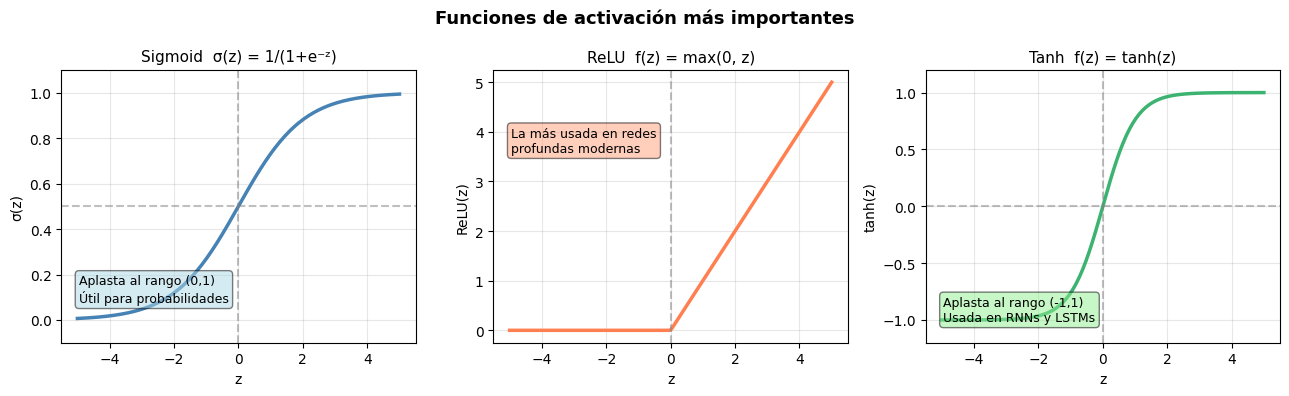

In [5]:
# Visualizar las funciones de activación más importantes
z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Sigmoid
axes[0].plot(z, sigmoid(z), color='steelblue', linewidth=2.5)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Sigmoid  σ(z) = 1/(1+e⁻ᶻ)', fontsize=11)
axes[0].set_xlabel('z')
axes[0].set_ylabel('σ(z)')
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Aplasta al rango (0,1)\nÚtil para probabilidades',
                 xy=(0.05, 0.15), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# ReLU
axes[1].plot(z, relu(z), color='coral', linewidth=2.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('ReLU  f(z) = max(0, z)', fontsize=11)
axes[1].set_xlabel('z')
axes[1].set_ylabel('ReLU(z)')
axes[1].grid(True, alpha=0.3)
axes[1].annotate('La más usada en redes\nprofundas modernas',
                 xy=(0.05, 0.7), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))

# Tanh
axes[2].plot(z, np.tanh(z), color='mediumseagreen', linewidth=2.5)
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Tanh  f(z) = tanh(z)', fontsize=11)
axes[2].set_xlabel('z')
axes[2].set_ylabel('tanh(z)')
axes[2].set_ylim(-1.2, 1.2)
axes[2].grid(True, alpha=0.3)
axes[2].annotate('Aplasta al rango (-1,1)\nUsada en RNNs y LSTMs',
                 xy=(0.05, 0.08), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.suptitle('Funciones de activación más importantes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

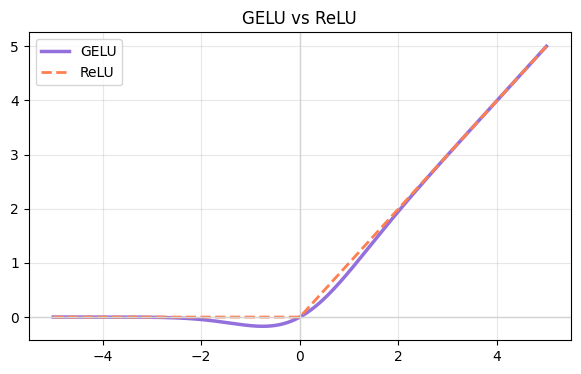

In [7]:
# Gelu es la funcion que usan los transformers modernos, como GPT y BERT
# la neurona no muere inmediatamente al no ser positivo el input
import numpy as np
import matplotlib.pyplot as plt

def gelu(z):
    return 0.5 * z * (1 + np.tanh(np.sqrt(2 / np.pi) * (z + 0.044715 * z**3)))

z = np.linspace(-5, 5, 1000)

plt.figure(figsize=(7, 4))
plt.plot(z, gelu(z),           label='GELU',    color='mediumpurple', linewidth=2.5)
plt.plot(z, np.maximum(0, z),  label='ReLU',    color='coral',        linewidth=2, linestyle='--')
plt.axhline(0, color='lightgray', linewidth=1)
plt.axvline(0, color='lightgray', linewidth=1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('GELU vs ReLU')
plt.show()

---
## PARTE 2 — Redes neuronales y gradiente descendente

### 2.1 De una neurona a una red

Una red neuronal es simplemente neuronas organizadas en **capas**:
- **Capa de entrada:** recibe los datos crudos
- **Capas ocultas:** transforman los datos progresivamente
- **Capa de salida:** produce la predicción final

La operación matemática entre capas es siempre la misma:
$$\mathbf{h} = f(\mathbf{W} \cdot \mathbf{x} + \mathbf{b})$$

Donde **W** es ahora una *matriz* de pesos (una fila por cada neurona de la capa).

In [9]:
# Red neuronal mínima: 2 entradas → 3 neuronas ocultas → 1 salida
# Implementada solo con NumPy, sin frameworks

np.random.seed(42)  # para reproducibilidad

class RedNeuronalMinima:
    """
    Red neuronal de 2 capas implementada desde cero.
    Arquitectura: entrada(2) → oculta(3) → salida(1)
    """
    
    def __init__(self, n_entrada=2, n_oculta=3, n_salida=1):
        # Inicialización aleatoria de pesos (pequeños, cerca de 0)
        # W1: matriz de pesos capa 1  → forma (n_oculta, n_entrada)
        self.W1 = np.random.randn(n_oculta, n_entrada) * 0.1
        self.b1 = np.zeros(n_oculta)
        
        # W2: matriz de pesos capa 2  → forma (n_salida, n_oculta)
        self.W2 = np.random.randn(n_salida, n_oculta) * 0.1
        self.b2 = np.zeros(n_salida)
    
    def forward(self, x):
        """Pasada hacia adelante (forward pass): calcula la predicción."""
        # Capa oculta
        self.z1 = self.W1 @ x + self.b1
        self.h1 = relu(self.z1)             # activación ReLU
        
        # Capa de salida
        self.z2 = self.W2 @ self.h1 + self.b2
        self.y_pred = sigmoid(self.z2)       # activación sigmoid → probabilidad
        
        return self.y_pred[0]  # devolver escalar


# Ejemplo de uso
red = RedNeuronalMinima()

print("Pesos iniciales (aleatorios):")
print(f"  W1 (capa oculta):  forma {red.W1.shape}")
print(f"  W2 (capa salida):  forma {red.W2.shape}")

# Dos ejemplos de entrada
ejemplos = [
    (np.array([0.8, 0.2]), "rojo intenso, poco verde"),
    (np.array([0.1, 0.9]), "poco rojo, verde intenso"),
]

print("\nPredicciones (pesos aún aleatorios, sin entrenar):")
for x, descripcion in ejemplos:
    pred = red.forward(x)
    print(f"  Entrada {x} ({descripcion}): {pred:.4f}")

print("\n   Aún no significan nada — los pesos son aleatorios.")
print("   El entrenamiento es lo que les da sentido.")

Pesos iniciales (aleatorios):
  W1 (capa oculta):  forma (3, 2)
  W2 (capa salida):  forma (1, 3)

Predicciones (pesos aún aleatorios, sin entrenar):
  Entrada [0.8 0.2] (rojo intenso, poco verde): 0.5030
  Entrada [0.1 0.9] (poco rojo, verde intenso): 0.5028

   Aún no significan nada — los pesos son aleatorios.
   El entrenamiento es lo que les da sentido.


### 2.2 ¿Cómo aprende la red? Gradiente descendente

El entrenamiento tiene una lógica muy simple:

1. La red hace una predicción
2. Comparamos la predicción con la respuesta correcta → calculamos el **error** (loss)
3. Calculamos en qué dirección mover cada peso para **reducir** ese error → eso es el **gradiente**
4. Movemos los pesos un pequeño paso en esa dirección → eso es el **learning rate**
5. Repetimos miles de veces

La función de error más común para clasificación es **Binary Cross-Entropy**:
$$L = -\frac{1}{N}\sum_{i}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

Donde $y_i$ es la etiqueta real y $\hat{y}_i$ es la predicción. No necesitas memorizar esta fórmula — lo importante es entender que **mide qué tan equivocado está el modelo**.

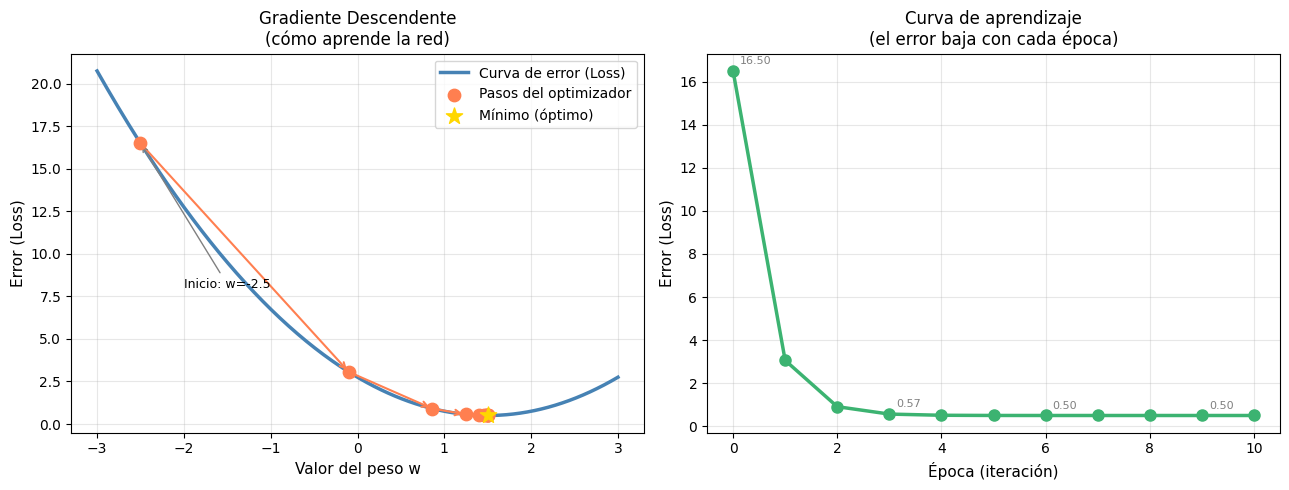


W inicial: -2.50  →  W final: 1.4996
Error inicial: 16.50  →  Error final: 0.5000

  En redes reales hay millones de pesos, no uno solo.
   El algoritmo 'backpropagation' calcula el gradiente
   para TODOS los pesos a la vez, usando la regla de la cadena.
   PyTorch y TensorFlow hacen esto automáticamente.


In [12]:
# Visualizar la intuición del gradiente descendente
# (sin implementar backprop completo — eso es trabajo de PyTorch)

# Imaginemos que el "error" depende de un solo peso w
# La forma de la curva de error es una parábola (simplificación)

w_vals = np.linspace(-3, 3, 300)
loss_vals = (w_vals - 1.5) ** 2 + 0.5   # mínimo en w=1.5

# Simular gradiente descendente
w = -2.5          # punto de inicio
lr = 0.3          # learning rate
historia_w = [w]
historia_loss = [(w - 1.5)**2 + 0.5]

for _ in range(10):
    gradiente = 2 * (w - 1.5)    # derivada de (w-1.5)² es 2(w-1.5)
    w = w - lr * gradiente        # actualizar peso
    historia_w.append(w)
    historia_loss.append((w - 1.5)**2 + 0.5)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: curva de error y pasos del gradiente
axes[0].plot(w_vals, loss_vals, 'steelblue', linewidth=2.5, label='Curva de error (Loss)')
axes[0].scatter(historia_w, historia_loss, c='coral', s=80, zorder=5, label='Pasos del optimizador')
for i in range(len(historia_w)-1):
    axes[0].annotate('', xy=(historia_w[i+1], historia_loss[i+1]),
                     xytext=(historia_w[i], historia_loss[i]),
                     arrowprops=dict(arrowstyle='->', color='coral', lw=1.5))
axes[0].scatter([1.5], [0.5], c='gold', s=150, zorder=6, marker='*', label='Mínimo (óptimo)')
axes[0].set_xlabel('Valor del peso w', fontsize=11)
axes[0].set_ylabel('Error (Loss)', fontsize=11)
axes[0].set_title('Gradiente Descendente\n(cómo aprende la red)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Inicio: w={historia_w[0]:.1f}', xy=(historia_w[0], historia_loss[0]),
                 xytext=(-2.0, 8), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='gray'))

# Gráfico 2: evolución del error por época
axes[1].plot(range(len(historia_loss)), historia_loss, 'o-', color='mediumseagreen',
             linewidth=2.5, markersize=8)
axes[1].set_xlabel('Época (iteración)', fontsize=11)
axes[1].set_ylabel('Error (Loss)', fontsize=11)
axes[1].set_title('Curva de aprendizaje\n(el error baja con cada época)', fontsize=12)
axes[1].grid(True, alpha=0.3)
for i, (x_i, y_i) in enumerate(zip(range(len(historia_loss)), historia_loss)):
    if i % 3 == 0:
        axes[1].annotate(f'{y_i:.2f}', (x_i, y_i), textcoords='offset points',
                        xytext=(5, 5), fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print(f"\nW inicial: {historia_w[0]:.2f}  →  W final: {historia_w[-1]:.4f}")
print(f"Error inicial: {historia_loss[0]:.2f}  →  Error final: {historia_loss[-1]:.4f}")
print(f"\n  En redes reales hay millones de pesos, no uno solo.")
print(f"   El algoritmo 'backpropagation' calcula el gradiente")
print(f"   para TODOS los pesos a la vez, usando la regla de la cadena.")
print(f"   PyTorch y TensorFlow hacen esto automáticamente.")

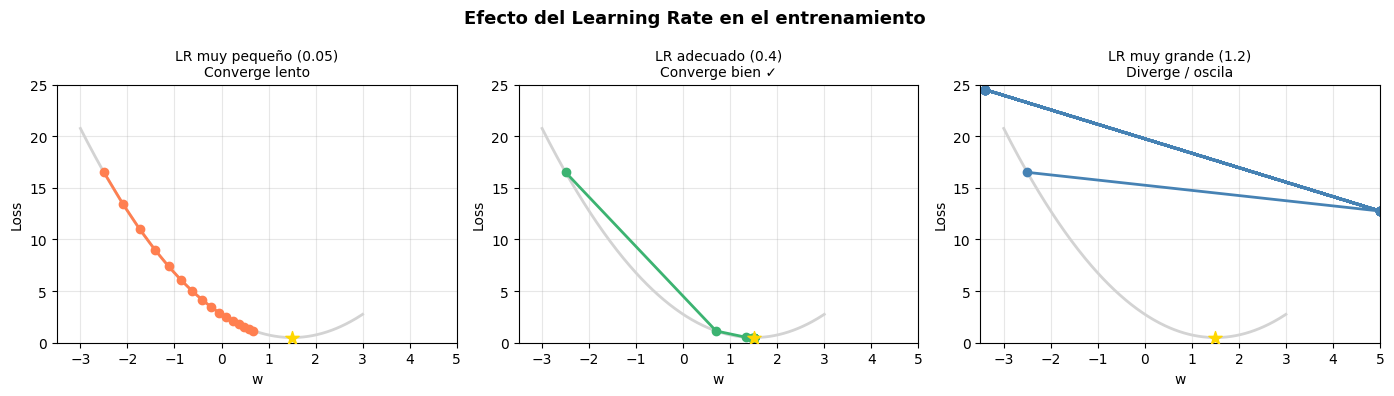

   En LLMs modernos, el learning rate NO es fijo.
   Optimizadores como Adam lo ajustan automáticamente
   para cada peso durante el entrenamiento.


In [14]:
# El efecto del learning rate — uno de los hiperparámetros más importantes

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    (0.05, 'coral',         'LR muy pequeño (0.05)\nConverge lento'),
    (0.4,  'mediumseagreen','LR adecuado (0.4)\nConverge bien ✓'),
    (1.2,  'steelblue',     'LR muy grande (1.2)\nDiverge / oscila'),
]

for ax, (lr_val, color, titulo) in zip(axes, configs):
    w_sim = -2.5
    hist_w_sim = [w_sim]
    hist_loss_sim = [(w_sim - 1.5)**2 + 0.5]
    
    for _ in range(15):
        grad = 2 * (w_sim - 1.5)
        w_sim = w_sim - lr_val * grad
        w_sim = np.clip(w_sim, -4, 5)   # limitar para visualización
        hist_w_sim.append(w_sim)
        hist_loss_sim.append((w_sim - 1.5)**2 + 0.5)
    
    ax.plot(w_vals, loss_vals, 'lightgray', linewidth=2)
    ax.plot(hist_w_sim, hist_loss_sim, 'o-', color=color, linewidth=2, markersize=6)
    ax.scatter([1.5], [0.5], c='gold', s=100, zorder=6, marker='*')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('w')
    ax.set_ylabel('Loss')
    ax.set_xlim(-3.5, 5)
    ax.set_ylim(0, 25)
    ax.grid(True, alpha=0.3)

plt.suptitle('Efecto del Learning Rate en el entrenamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("   En LLMs modernos, el learning rate NO es fijo.")
print("   Optimizadores como Adam lo ajustan automáticamente")
print("   para cada peso durante el entrenamiento.")

---
## PARTE 3 — NLP antes de los LLMs: Bag of Words y TF-IDF

### 3.1 El problema fundamental: ¿cómo le damos texto a una red neuronal?

Las redes neuronales solo entienden números. El texto hay que convertirlo.

El enfoque clásico (pre-2017) era **Bag of Words**: representar cada texto como un vector que cuenta cuántas veces aparece cada palabra del vocabulario. La posición y el contexto de las palabras se ignoran completamente.

Luego vino **TF-IDF** (Term Frequency - Inverse Document Frequency), que mejoraba BoW penalizando las palabras muy frecuentes ("el", "la", "de") y premiando las palabras raras y específicas.

In [4]:
# Dataset de reseñas de películas en español (simulado)
resenas = [
    "La película es excelente, me encantó la historia",
    "Muy buena actuación, historia emocionante y bien dirigida",
    "Una obra maestra del cine latinoamericano, impresionante",
    "Buena película aunque algo lenta en el segundo acto",
    "Terrible actuación, historia aburrida y predecible",
    "Mala película, pérdida de tiempo, muy decepcionante",
    "Pésima dirección, actores sin carisma, historia sin sentido",
    "No me gustó para nada, muy mala y aburrida",
]
etiquetas = [1, 1, 1, 1, 0, 0, 0, 0]  # 1=positiva, 0=negativa

# ── Bag of Words ──────────────────────────────────────────
vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(resenas).toarray()

vocabulario = vectorizer_bow.get_feature_names_out()

print("REPRESENTACIÓN BAG OF WORDS")
print("=" * 55)
print(f"Tamaño del vocabulario: {len(vocabulario)} palabras únicas")
print(f"Cada reseña se convierte en un vector de {len(vocabulario)} números")
print()
print(f"Primeras 15 palabras del vocabulario:")
print(f"  {list(vocabulario[:15])}")
print()
print("Representación de la primera reseña:")
print(f"  Texto:  '{resenas[0]}'")
print(f"  Vector: {X_bow[0]}")
print()

# Mostrar qué palabras aparecen
palabras_presentes = [(vocabulario[i], X_bow[0][i]) 
                      for i in range(len(vocabulario)) 
                      if X_bow[0][i] > 0]
print("  Palabras presentes:")
for palabra, conteo in palabras_presentes:
    print(f"    '{palabra}': {int(conteo)} vez/veces")

REPRESENTACIÓN BAG OF WORDS
Tamaño del vocabulario: 45 palabras únicas
Cada reseña se convierte en un vector de 45 números

Primeras 15 palabras del vocabulario:
  ['aburrida', 'acto', 'actores', 'actuación', 'algo', 'aunque', 'bien', 'buena', 'carisma', 'cine', 'de', 'decepcionante', 'del', 'dirección', 'dirigida']

Representación de la primera reseña:
  Texto:  'La película es excelente, me encantó la historia'
  Vector: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 0 2 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0]

  Palabras presentes:
    'encantó': 1 vez/veces
    'es': 1 vez/veces
    'excelente': 1 vez/veces
    'historia': 1 vez/veces
    'la': 2 vez/veces
    'me': 1 vez/veces
    'película': 1 vez/veces


In [5]:
# ── TF-IDF ────────────────────────────────────────────────
vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(resenas).toarray()

print("REPRESENTACIÓN TF-IDF")
print("=" * 55)
print(f"Misma dimensión: {X_tfidf.shape[1]} palabras")
print(f"Pero ahora los valores son pesos continuos, no conteos")
print()
print("Comparación para la primera reseña:")
print(f"  Texto: '{resenas[0]}'")
print()

# Mostrar las palabras más importantes según TF-IDF
vocab_tfidf = vectorizer_tfidf.get_feature_names_out()
indices_ordenados = np.argsort(X_tfidf[0])[::-1]
print("  Palabras más importantes (mayor peso TF-IDF):")
for idx in indices_ordenados[:6]:
    if X_tfidf[0][idx] > 0:
        print(f"    '{vocab_tfidf[idx]}': {X_tfidf[0][idx]:.4f}")

print()
print("💡 TF-IDF penaliza palabras como 'la', 'es', 'me' (muy frecuentes)")
print("   y premia palabras específicas como 'excelente', 'encantó'.")

REPRESENTACIÓN TF-IDF
Misma dimensión: 45 palabras
Pero ahora los valores son pesos continuos, no conteos

Comparación para la primera reseña:
  Texto: 'La película es excelente, me encantó la historia'

  Palabras más importantes (mayor peso TF-IDF):
    'la': 0.6809
    'excelente': 0.3405
    'es': 0.3405
    'encantó': 0.3405
    'me': 0.2853
    'película': 0.2462

💡 TF-IDF penaliza palabras como 'la', 'es', 'me' (muy frecuentes)
   y premia palabras específicas como 'excelente', 'encantó'.


In [6]:
# Clasificador de sentimiento usando TF-IDF + Regresión Logística
# (el pipeline clásico de NLP antes de los Transformers)

modelo_clasico = LogisticRegression(max_iter=1000)
modelo_clasico.fit(X_tfidf, etiquetas)

# Evaluar en el mismo conjunto (dataset pequeño, solo para demostración)
predicciones = modelo_clasico.predict(X_tfidf)
accuracy = accuracy_score(etiquetas, predicciones)

print("CLASIFICADOR CLÁSICO: TF-IDF + Regresión Logística")
print("=" * 55)
print(f"Accuracy en datos de entrenamiento: {accuracy*100:.0f}%")
print()

# Probar con reseñas nuevas
nuevas_resenas = [
    "Increíble película, muy recomendada",
    "Una película terrible, no la vean",
    "El actor principal es muy bueno pero la historia es aburrida",  # ambigua
]

X_nuevas = vectorizer_tfidf.transform(nuevas_resenas).toarray()
preds = modelo_clasico.predict(X_nuevas)
probs = modelo_clasico.predict_proba(X_nuevas)

print("Predicciones en reseñas nuevas:")
for resena, pred, prob in zip(nuevas_resenas, preds, probs):
    etiqueta = "✅ POSITIVA" if pred == 1 else "❌ NEGATIVA"
    confianza = max(prob) * 100
    print(f"  '{resena[:50]}...'" if len(resena) > 50 else f"  '{resena}'")
    print(f"  → {etiqueta} (confianza: {confianza:.0f}%)")
    print()

CLASIFICADOR CLÁSICO: TF-IDF + Regresión Logística
Accuracy en datos de entrenamiento: 100%

Predicciones en reseñas nuevas:
  'Increíble película, muy recomendada'
  → ❌ NEGATIVA (confianza: 50%)

  'Una película terrible, no la vean'
  → ✅ POSITIVA (confianza: 52%)

  'El actor principal es muy bueno pero la historia e...'
  → ✅ POSITIVA (confianza: 54%)



In [8]:
# Las limitaciones del enfoque clásico — por qué era insuficiente
print("LIMITACIONES DEL ENFOQUE CLÁSICO (BoW / TF-IDF)")
print("=" * 55)

casos_problematicos = [
    (
        "La dirección y la actuacion fueron buenos",
        "actué y seguí la dirección de la casa."
    ),
    (
        "No me gustó la película",
        "La película me gustó mucho"
    ),
    (
        "El film fue genial",
        "La película fue excelente"
    ),
]

for frase1, frase2 in casos_problematicos:
    vec1 = vectorizer_tfidf.transform([frase1]).toarray()[0]
    vec2 = vectorizer_tfidf.transform([frase2]).toarray()[0]
    
    # Similitud coseno entre los dos vectores
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 > 0 and norm2 > 0:
        similitud = np.dot(vec1, vec2) / (norm1 * norm2)
    else:
        similitud = 0.0
    
    print(f"  Frase 1: '{frase1}'")
    print(f"  Frase 2: '{frase2}'")
    print(f"  Similitud TF-IDF: {similitud:.2f}")
    print()

print("─" * 55)
print("CONCLUSIÓN: el enfoque clásico no entiende contexto ni semántica.")
print("Esto motivó la búsqueda de representaciones mejores → Embeddings → Transformers.")

LIMITACIONES DEL ENFOQUE CLÁSICO (BoW / TF-IDF)
  Frase 1: 'La dirección y la actuacion fueron buenos'
  Frase 2: 'actué y seguí la dirección de la casa.'
  Similitud TF-IDF: 0.91

  Frase 1: 'No me gustó la película'
  Frase 2: 'La película me gustó mucho'
  Similitud TF-IDF: 0.87

  Frase 1: 'El film fue genial'
  Frase 2: 'La película fue excelente'
  Similitud TF-IDF: 0.00

───────────────────────────────────────────────────────
CONCLUSIÓN: el enfoque clásico no entiende contexto ni semántica.
Esto motivó la búsqueda de representaciones mejores → Embeddings → Transformers.


---
## PARTE 4 — El salto a los Transformers

### 4.1 Embeddings: representaciones densas del significado

La solución al problema de BoW fueron los **embeddings**: vectores densos de cientos de dimensiones que capturan el *significado* de las palabras, no solo su presencia.

**La propiedad clave:** palabras con significado similar tienen vectores similares (cercanos en el espacio vectorial).

```
BoW:    "rey"  → [0, 0, 0, 1, 0, 0, 0, ...]   (vector disperso, miles de dims)
Embedding: "rey"  → [0.25, -0.13, 0.87, ...]  (vector denso, 768 dims en BERT)
```

El famoso ejemplo: `rey - hombre + mujer ≈ reina`  
Eso no puede existir en BoW. En embeddings, sí.

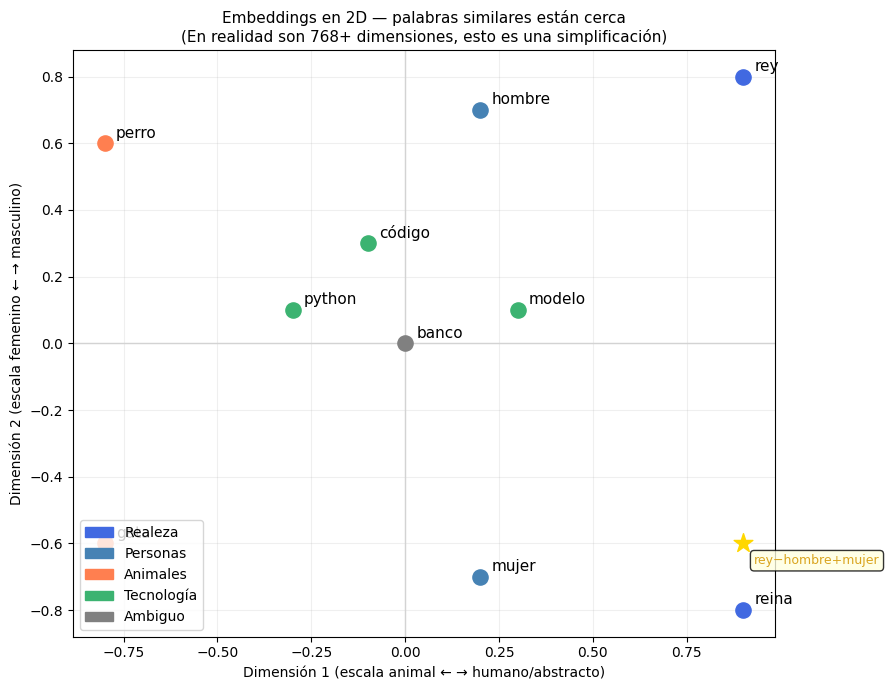

⭐ La estrella dorada es 'rey - hombre + mujer'
   Resultado: [ 0.9 -0.6]
   Reina está en: [ 0.9 -0.8]
   → ¡Casi coinciden! Eso es la magia de los embeddings.


In [ ]:
# Simulación de embeddings en 2D para visualizar la intuición
# (En realidad son 768, 1024 o más dimensiones — no podemos visualizarlas directamente)

# Embeddings simplificados en 2D (inventados para la demo)
# Dimensión 1: escala animal↔humano
# Dimensión 2: escala femenino↔masculino
palabras_2d = {
    'rey':    np.array([ 0.9,  0.8]),
    'reina':  np.array([ 0.9, -0.8]),
    'hombre': np.array([ 0.2,  0.7]),
    'mujer':  np.array([ 0.2, -0.7]),
    'perro':  np.array([-0.8,  0.6]),
    'gata':   np.array([-0.8, -0.6]),
    'banco':  np.array([ 0.0,  0.0]),  # ambiguo → centro
    'python': np.array([-0.3,  0.1]),
    'código': np.array([-0.1,  0.3]),
    'modelo': np.array([ 0.3,  0.1]),
}

fig, ax = plt.subplots(figsize=(9, 7))

colores = {
    'rey': 'royalblue', 'reina': 'royalblue',
    'hombre': 'steelblue', 'mujer': 'steelblue',
    'perro': 'coral', 'gata': 'coral',
    'banco': 'gray',
    'python': 'mediumseagreen', 'código': 'mediumseagreen', 'modelo': 'mediumseagreen',
}

for palabra, vec in palabras_2d.items():
    ax.scatter(vec[0], vec[1], s=120, color=colores.get(palabra, 'gray'), zorder=5)
    ax.annotate(palabra, vec, textcoords='offset points', xytext=(8, 4), fontsize=11)

# Mostrar la analogía rey - hombre + mujer ≈ reina
resultado_analogia = palabras_2d['rey'] - palabras_2d['hombre'] + palabras_2d['mujer']
ax.scatter(*resultado_analogia, s=200, color='gold', zorder=6, marker='*')
ax.annotate('rey−hombre+mujer', resultado_analogia,
            textcoords='offset points', xytext=(8, -15),
            fontsize=9, color='goldenrod',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.axhline(0, color='lightgray', linewidth=1)
ax.axvline(0, color='lightgray', linewidth=1)
ax.set_xlabel('Dimensión 1 (escala animal ← → humano/abstracto)', fontsize=10)
ax.set_ylabel('Dimensión 2 (escala femenino ← → masculino)', fontsize=10)
ax.set_title('Embeddings en 2D — palabras similares están cerca\n'
             '(En realidad son 768+ dimensiones, esto es una simplificación)', fontsize=11)
ax.grid(True, alpha=0.2)
leyenda = [
    mpatches.Patch(color='royalblue', label='Realeza'),
    mpatches.Patch(color='steelblue', label='Personas'),
    mpatches.Patch(color='coral', label='Animales'),
    mpatches.Patch(color='mediumseagreen', label='Tecnología'),
    mpatches.Patch(color='gray', label='Ambiguo'),
]
ax.legend(handles=leyenda, loc='lower left')
plt.tight_layout()
plt.show()

print("⭐ La estrella dorada es 'rey - hombre + mujer'")
print(f"   Resultado: {resultado_analogia}")
print(f"   Reina está en: {palabras_2d['reina']}")
print(f"   → ¡Casi coinciden! Eso es la magia de los embeddings.")

### 4.2 La arquitectura Transformer: tres ideas que cambiaron todo

El paper "Attention Is All You Need" (Vaswani et al., 2017) introdujo la arquitectura que está detrás de todos los LLMs modernos. Sus tres ideas clave:

**Idea 1 — Self-Attention:** cada token "mira" a todos los demás tokens de la secuencia y decide cuánta atención prestarle a cada uno. Esto resuelve el problema del contexto que tenía BoW.

**Idea 2 — Procesamiento paralelo:** a diferencia de las RNNs (que procesaban token por token), los Transformers procesan toda la secuencia a la vez. Eso permite entrenarlos en clusters de GPUs masivos.

**Idea 3 — Positional Encoding:** como el modelo procesa todo en paralelo, necesita saber el orden de los tokens. Se agrega una señal matemática que codifica la posición.

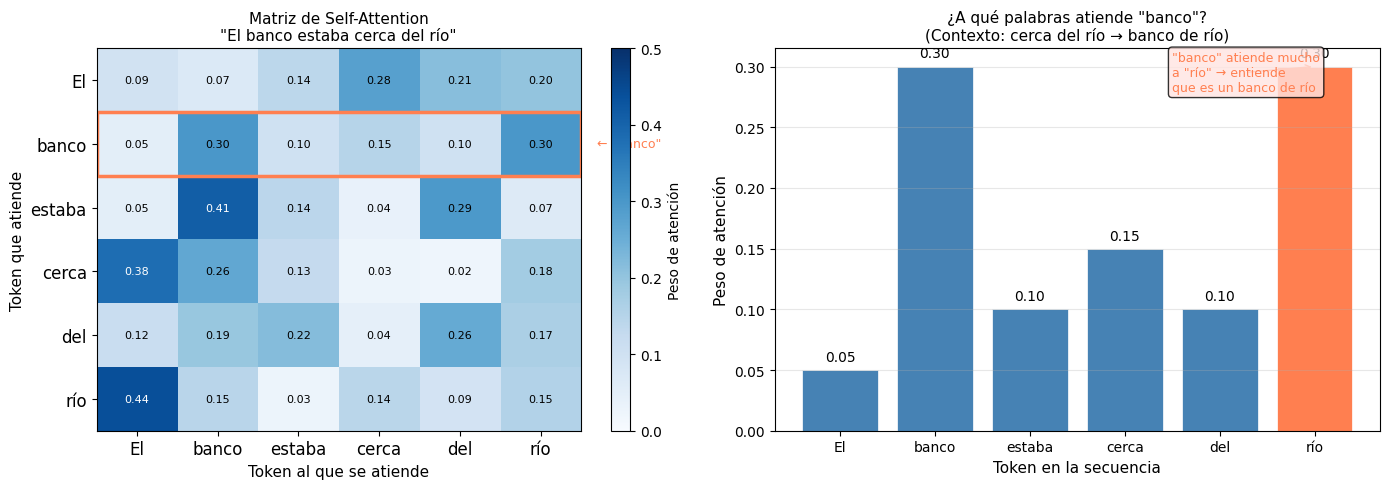

💡 Esto es exactamente lo que hace un LLM cuando procesa texto:
   cada token decide cuánto 'atender' a cada otro token para
   entender su significado en ese contexto específico.
   Por eso 'banco' significa cosas distintas en distintos contextos.


In [ ]:
# Visualizar el mecanismo de self-attention de forma intuitiva
# (simplificado: solo mostramos los pesos de atención, no los calculamos realmente)

frase = ["El", "banco", "estaba", "cerca", "del", "río"]
n = len(frase)

# Pesos de atención simulados para el token 'banco'
# En el contexto 'banco cerca del río', 'banco' debería atender más a 'río'
# (indicando que es un banco de río, no un banco financiero)
atencion_banco = np.array([0.05, 0.30, 0.10, 0.15, 0.10, 0.30])
atencion_banco /= atencion_banco.sum()  # normalizar

# Matriz de atención completa (simulada)
np.random.seed(7)
matriz_atencion = np.random.dirichlet(np.ones(n) * 2, size=n)
# Ajustar 'banco' para que atienda más a 'río'
matriz_atencion[1] = atencion_banco

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: heatmap de la matriz de atención
im = axes[0].imshow(matriz_atencion, cmap='Blues', aspect='auto', vmin=0, vmax=0.5)
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(n))
axes[0].set_xticklabels(frase, fontsize=12)
axes[0].set_yticklabels(frase, fontsize=12)
axes[0].set_xlabel('Token al que se atiende', fontsize=11)
axes[0].set_ylabel('Token que atiende', fontsize=11)
axes[0].set_title('Matriz de Self-Attention\n"El banco estaba cerca del río"', fontsize=11)
plt.colorbar(im, ax=axes[0], label='Peso de atención')

# Agregar valores en las celdas
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, f'{matriz_atencion[i,j]:.2f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if matriz_atencion[i,j] > 0.3 else 'black')

# Resaltar la fila de 'banco'
axes[0].add_patch(plt.Rectangle((-0.5, 0.5), n, 1, fill=False,
                                edgecolor='coral', linewidth=2.5))
axes[0].text(n-0.3, 1, '← "banco"', color='coral', fontsize=9, va='center')

# Gráfico 2: atención del token 'banco' específicamente
colores_barra = ['steelblue' if t != 'río' else 'coral' for t in frase]
bars = axes[1].bar(frase, atencion_banco, color=colores_barra, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Token en la secuencia', fontsize=11)
axes[1].set_ylabel('Peso de atención', fontsize=11)
axes[1].set_title('¿A qué palabras atiende "banco"?\n'
                  '(Contexto: cerca del río → banco de río)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, atencion_banco):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)
axes[1].annotate('"banco" atiende mucho\na "río" → entiende\nque es un banco de río',
                 xy=(5, atencion_banco[5]), xytext=(3.5, 0.28),
                 arrowprops=dict(arrowstyle='->', color='coral'),
                 fontsize=9, color='coral',
                 bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.8))

plt.tight_layout()
plt.show()
print("💡 Esto es exactamente lo que hace un LLM cuando procesa texto:")
print("   cada token decide cuánto 'atender' a cada otro token para")
print("   entender su significado en ese contexto específico.")
print("   Por eso 'banco' significa cosas distintas en distintos contextos.")

---
## PARTE 5 — Conectando todo: ¿qué hace un LLM cuando responde?

Ahora que entiendes las piezas, veamos el proceso completo de principio a fin.

In [31]:
# Simulación del proceso completo de un LLM al generar texto
# (sin un LLM real — simulando los pasos conceptuales)

print("PROCESO COMPLETO DE UN LLM AL GENERAR UNA RESPUESTA")
print("=" * 60)
print()

prompt = "La capital de Francia es"
print(f"📥 PROMPT:  '{prompt}'")
print()

print("PASO 1 — Tokenización")
print("─" * 40)
# Simulación (tokenización real varía por modelo)
tokens_simulados = ["La", " capital", " de", " Francia", " es"]
ids_simulados    = [    2,      4821,    450,     7272,   643]
for tok, id_ in zip(tokens_simulados, ids_simulados):
    print(f"  '{tok}' → ID {id_}")
print()

print("PASO 2 — Embedding (cada token → vector denso)")
print("─" * 40)
print("  'Francia' → [0.23, -0.41, 0.87, 0.12, ...] (768 dimensiones)")
print("  'capital' → [0.51,  0.33, 0.29, -0.8, ...] (768 dimensiones)")
print("  + Positional Encoding (posición 3 y 1 respectivamente)")
print()

print("PASO 3 — Self-Attention (N veces, un bloque por capa)")
print("─" * 40)
print("  Cada token actualiza su representación mirando todos los demás.")
print("  'es' atiende fuertemente a 'capital' y 'Francia'")
print("  → su embedding ahora encode 'la capital de un país'")
print()

print("PASO 4 — Predicción del siguiente token")
print("─" * 40)
# Distribución de probabilidad simulada
candidatos = ["París", "Lyon", "Madrid", "Berlín", "Roma"]
probs_sim  = [  0.94,   0.02,    0.02,    0.01,   0.01]

for candidato, prob in zip(candidatos, probs_sim):
    barra = '█' * int(prob * 40)
    print(f"  {candidato:8s}: {barra} {prob*100:.1f}%")
print()

print("PASO 5 — Sampling (elegir el token)")
print("─" * 40)
print("  Con temperature=0.0: siempre elige 'París' (el más probable)")
print("  Con temperature=1.0: samplea según la distribución")
print("  Token elegido: 'París'")
print()

print("PASO 6 — 'París' se agrega al contexto y el proceso se repite")
print("─" * 40)
print("  Nuevo contexto: 'La capital de Francia es París'")
print("  → Predice el siguiente token: '.', ',' , 'y', etc.")
print()
print("  Este proceso (pasos 1-6) se repite hasta:")
print("  • Generar el token especial <EOS> (End of Sequence)")
print("  • Alcanzar el límite de max_tokens")
print("  • Detectar un stop_sequence configurado")
print()
print("📤 RESPUESTA FINAL: 'La capital de Francia es París.'")

PROCESO COMPLETO DE UN LLM AL GENERAR UNA RESPUESTA

📥 PROMPT:  'La capital de Francia es'

PASO 1 — Tokenización
────────────────────────────────────────
  'La' → ID 2
  ' capital' → ID 4821
  ' de' → ID 450
  ' Francia' → ID 7272
  ' es' → ID 643

PASO 2 — Embedding (cada token → vector denso)
────────────────────────────────────────
  'Francia' → [0.23, -0.41, 0.87, 0.12, ...] (768 dimensiones)
  'capital' → [0.51,  0.33, 0.29, -0.8, ...] (768 dimensiones)
  + Positional Encoding (posición 3 y 1 respectivamente)

PASO 3 — Self-Attention (N veces, un bloque por capa)
────────────────────────────────────────
  Cada token actualiza su representación mirando todos los demás.
  'es' atiende fuertemente a 'capital' y 'Francia'
  → su embedding ahora encode 'la capital de un país'

PASO 4 — Predicción del siguiente token
────────────────────────────────────────
  París   : █████████████████████████████████████ 94.0%
  Lyon    :  2.0%
  Madrid  :  2.0%
  Berlín  :  1.0%
  Roma    :  1.0%

P